In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub as kh
import os
import keras
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from helper import *
from keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Input, BatchNormalization

%matplotlib inline

In [2]:
training = True

In [3]:
tf.random.set_seed(42)

In [4]:
path = kh.dataset_download("palbha/cmapss-jet-engine-simulated-data")

In [5]:
col_names = ['Unit', 'Cycle Time', 'Op1', 'Op2', 'Op3'] + [f'Sensor {_+1}' for _ in range(23)]
df = pd.read_csv(os.path.join(path, 'train_FD001.txt'), sep=' ', header=None, names=col_names)
df_test = pd.read_csv(os.path.join(path, 'test_FD001.txt'), sep=' ', header=None, names=col_names)

In [6]:
df.head()

,Unit,Cycle Time,Op1,Op2,Op3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Sensor 22,Sensor 23
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN


In [7]:
# Using to_string with specific formatting
with open('data_summary_FD001.txt', 'w') as f:
    f.write("CMAPSS Dataset Summary Statistics\n")
    f.write("="*30 + "\n")
    f.write(df.describe().transpose().to_string()) # Transpose makes it easier to read if you have many sensors

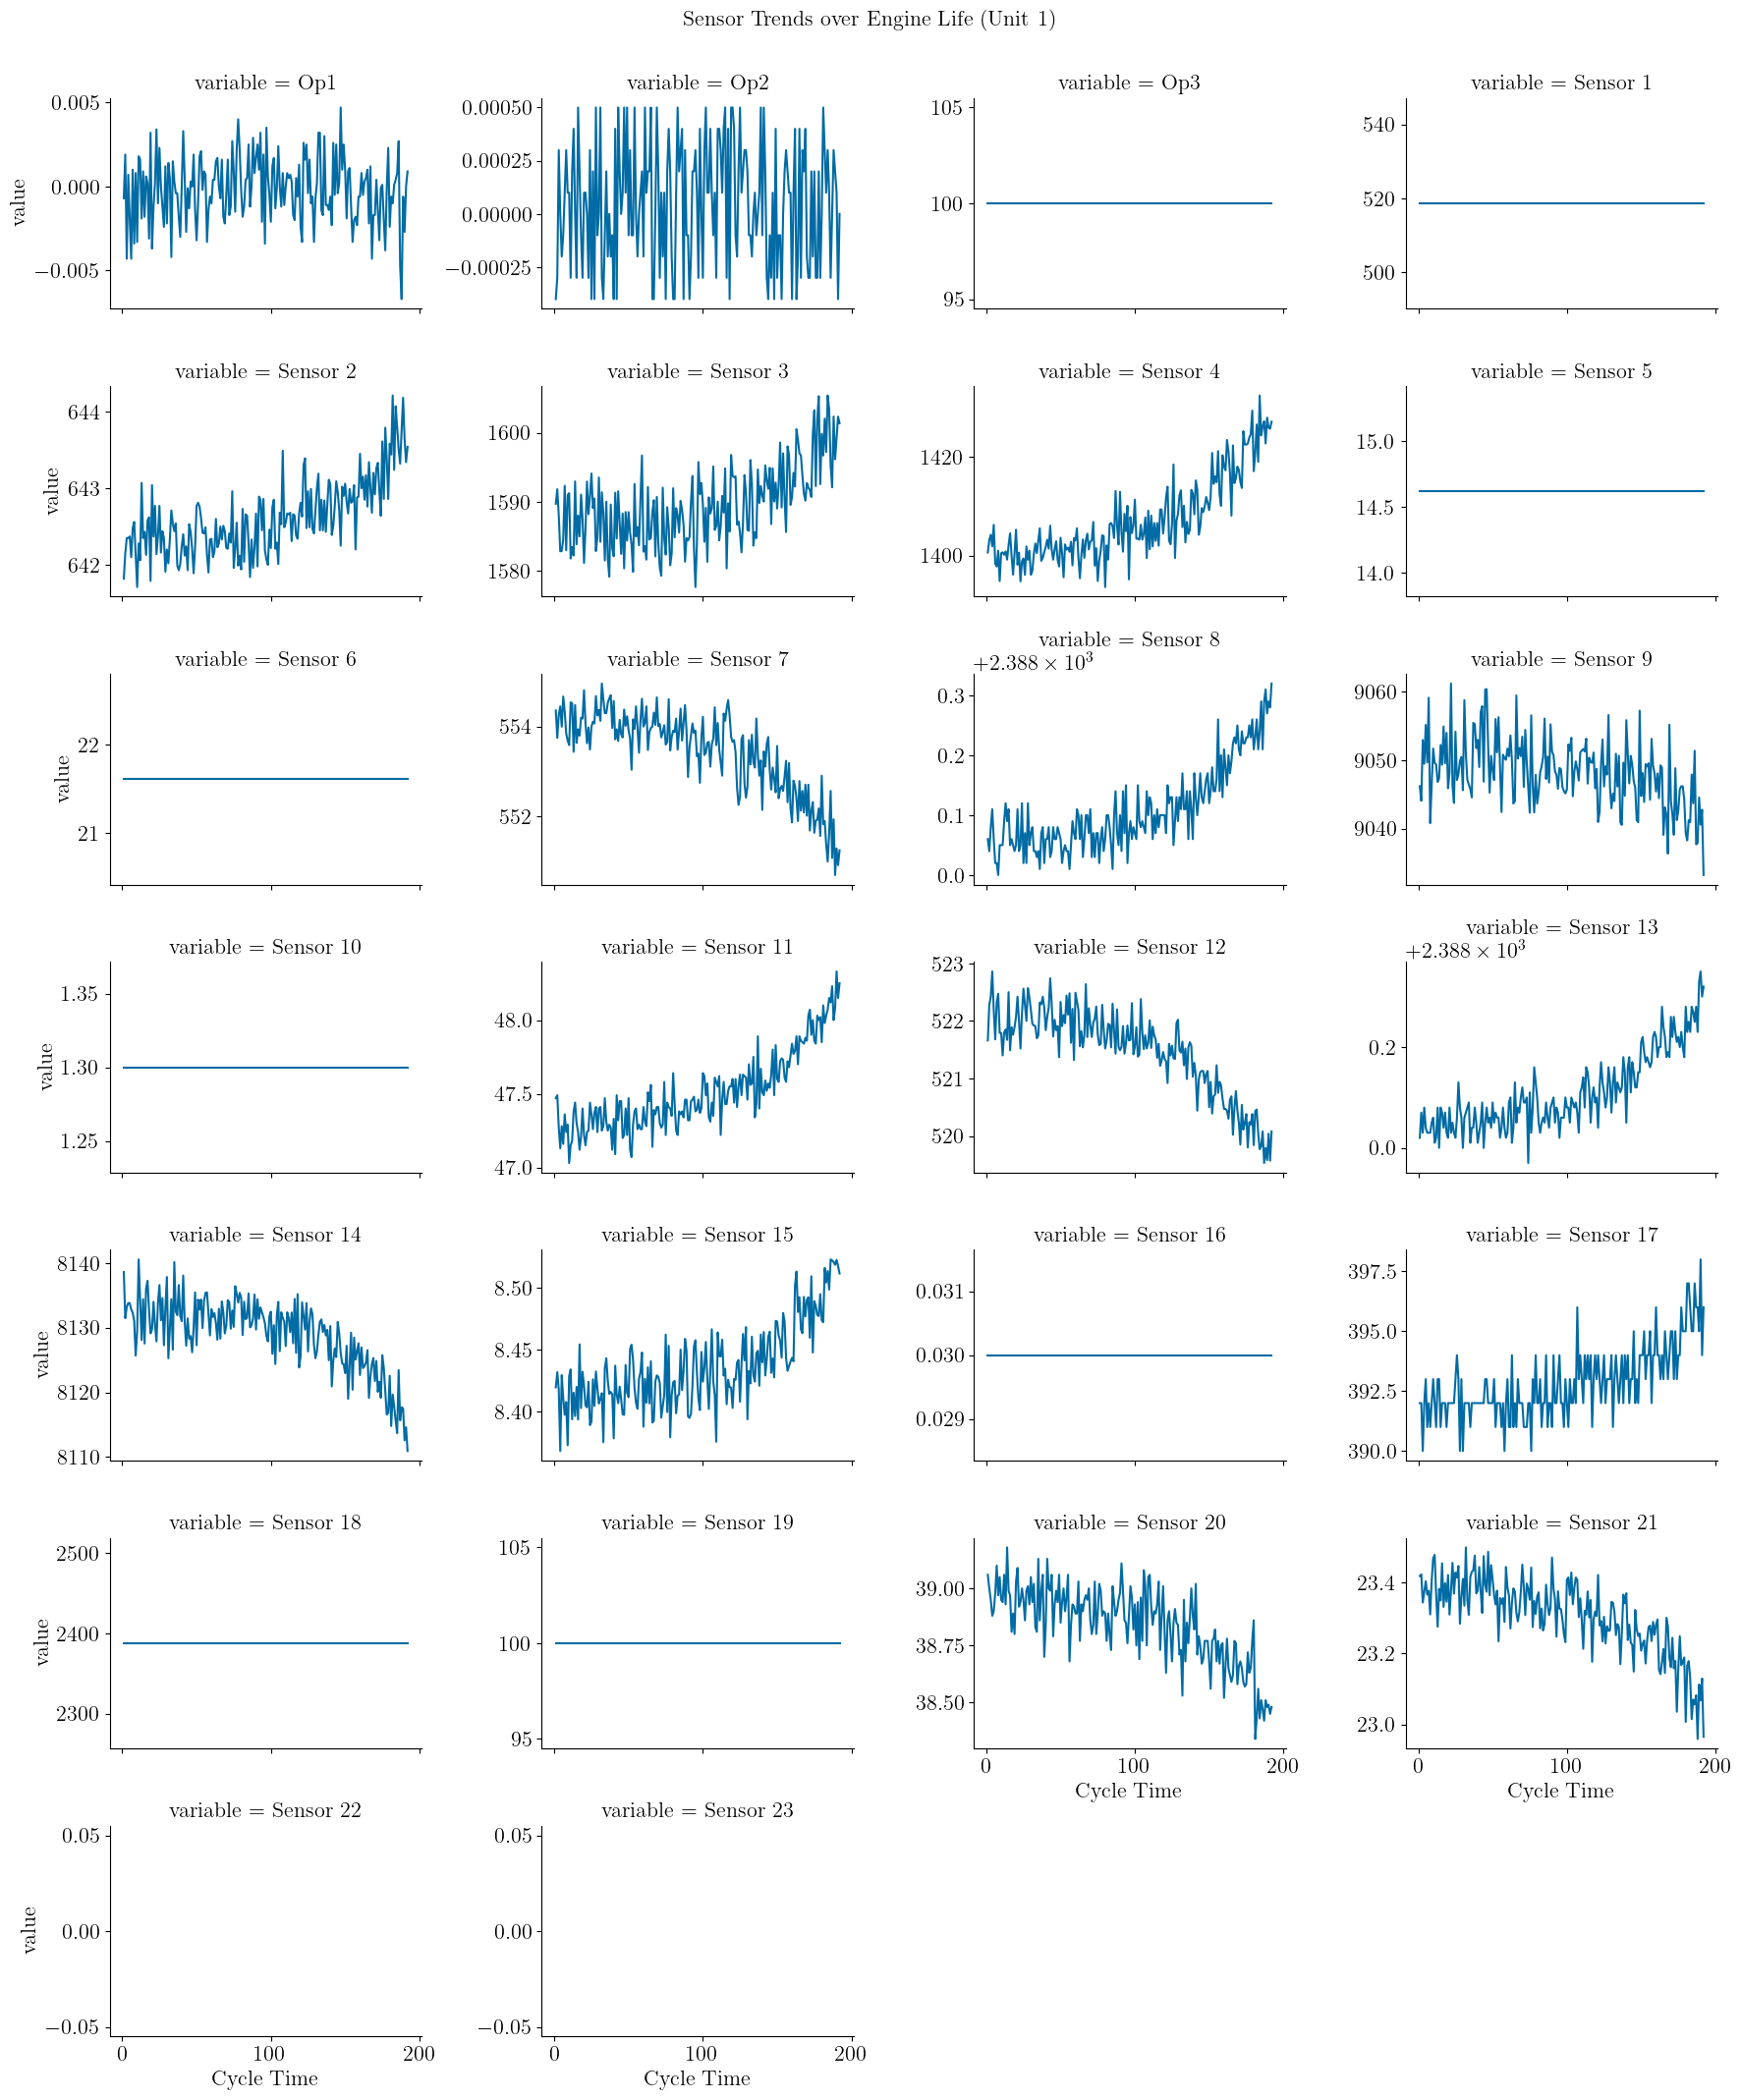

In [8]:
unit_data = df[df['Unit'] == 1]
plot_data = unit_data.melt(id_vars='Cycle Time', value_vars=['Op1', 'Op2', 'Op3'] + [f'Sensor {_+1}' for _ in range(23)])

# 2. Create a grid of plots
g = sns.FacetGrid(plot_data, col="variable", col_wrap=4, sharey=False, aspect=1.5)
g.map(sns.lineplot, "Cycle Time", "value")

# Add a title and adjust layout
g.fig.suptitle('Sensor Trends over Engine Life (Unit 1)', y=1.02, fontsize=16)
plt.show()

In [9]:
cols_to_drop = ['Sensor 1', 'Sensor 5', 'Sensor 6', 'Sensor 10', 'Sensor 16', 'Sensor 18', 'Sensor 19', 'Sensor 22', 'Sensor 23']
relevant_sensors = [f'Sensor {_+1}' for _ in range(23) if _ not in (0, 4, 5, 9, 15, 17, 18, 21, 22)]
ops = ['Op1', 'Op2']
df = df.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)
df.head()

,Unit,Cycle Time,Op1,Op2,Op3,Sensor 2,Sensor 3,Sensor 4,Sensor 7,Sensor 8,Sensor 9,Sensor 11,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 17,Sensor 20,Sensor 21
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


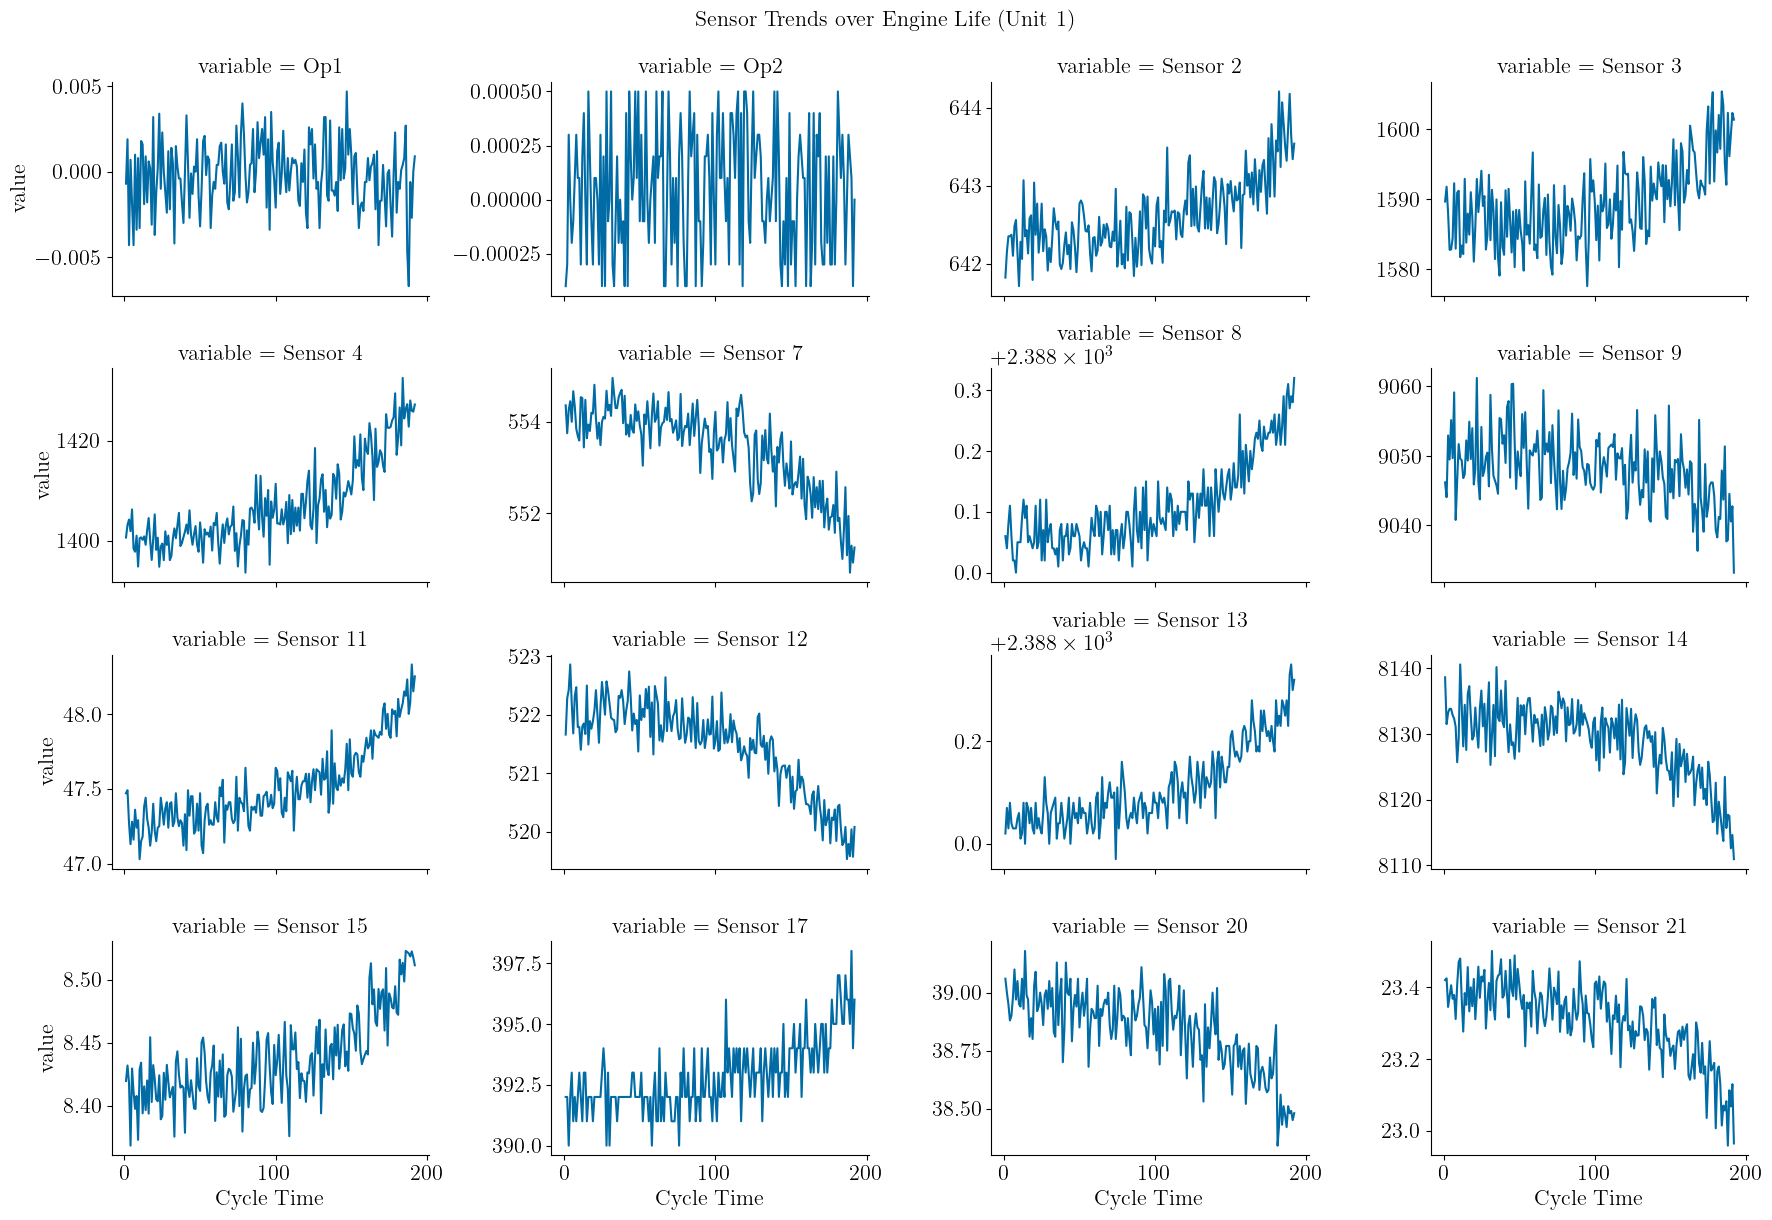

In [10]:
unit_data = df[df['Unit'] == 1]
plot_data = unit_data.melt(id_vars='Cycle Time', value_vars=ops+relevant_sensors)

# 2. Create a grid of plots
g = sns.FacetGrid(plot_data, col="variable", col_wrap=4, sharey=False, aspect=1.5)
g.map(sns.lineplot, "Cycle Time", "value")

# Add a title and adjust layout
g.fig.suptitle('Sensor Trends over Engine Life (Unit 1)', y=1.02, fontsize=16)
plt.show()

In [11]:
print(relevant_sensors)

['Sensor 2', 'Sensor 3', 'Sensor 4', 'Sensor 7', 'Sensor 8', 'Sensor 9', 'Sensor 11', 'Sensor 12', 'Sensor 13', 'Sensor 14', 'Sensor 15', 'Sensor 17', 'Sensor 20', 'Sensor 21']


In [12]:
wsize = 50

# Fit ONLY on the first 50 cycles of the training data 
# This defines the 0.0 to 1.0 range based on HEALTHY engines
scaler = MinMaxScaler()
scaler.fit(df.groupby('Unit').head(wsize)[ops + relevant_sensors])

# Transform everything using that "Healthy Range"
df[ops + relevant_sensors] = scaler.transform(df[ops + relevant_sensors])
df_test[ops + relevant_sensors] = scaler.transform(df_test[ops + relevant_sensors])

In [13]:
def gen_train_windows_multi(df, window_size, op_cols, sensor_cols):
    X, Y = [], []
    all_features = op_cols + sensor_cols
    
    for unit in df['Unit'].unique():
        # Get all relevant data for this unit
        unit_data = df[df['Unit'] == unit]
        
        # We only train on the 'Healthy' start (first 50 cycles)
        # Input (X) gets Ops + Sensors | Target (Y) gets Sensors Only
        input_data = unit_data[all_features].values[:50]
        target_data = unit_data[sensor_cols].values[:50]
        
        if len(input_data) >= window_size:
            for i in range(len(input_data) - window_size + 1):
                X.append(input_data[i:i+window_size])
                Y.append(target_data[i:i+window_size])
                
    return np.array(X), np.array(Y)

In [14]:
def gen_test_windows_multi(df, window_size, op_cols, sensor_cols):
    X, Y_actual, unit_ids = [], [], []
    all_features = op_cols + sensor_cols
    
    for unit in df['Unit'].unique():
        unit_data = df[df['Unit'] == unit]
        
        if len(unit_data) >= window_size:
            # X MUST have (Ops + Sensors) to match model Input
            X.append(unit_data[all_features].values[-window_size:])
            
            # Y_actual MUST have (Sensors Only) to match model Output
            Y_actual.append(unit_data[sensor_cols].values[-window_size:])
            
            unit_ids.append(unit)
            
    return np.array(X), np.array(Y_actual), unit_ids

In [15]:
X_train, Y_train = gen_train_windows_multi(df, wsize, ops, relevant_sensors)
X_test, Y_test, test_units = gen_test_windows_multi(df_test, wsize, ops, relevant_sensors)

In [16]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(100, 50, 16)
(100, 50, 14)
(93, 50, 16)
(93, 50, 14)


In [17]:
# Define dimensions based on your lists
n_inputs = len(ops) + len(relevant_sensors) # Total features in X_train
n_targets = len(relevant_sensors)            # Only the sensors in Y_train

# 1. Input Layer
# Matches the shape (window_size, total_features)
inputs = Input(shape=(wsize, n_inputs))

# 2. Encoder
# Processes both Ops and Sensors to find the 'hidden' health state
encoder = LSTM(64, activation='tanh', return_sequences=False)(inputs)

# 3. Bottleneck
# Bridges the single 'thought vector' back into a sequence
bottleneck = RepeatVector(wsize)(encoder)

# 4. Decoder
decoder = LSTM(64, activation='tanh', return_sequences=True)(bottleneck)

# 5. Output Layer
# This MUST match n_targets so it only reconstructs the health sensors
outputs = TimeDistributed(Dense(n_targets))(decoder)

# Create the Model object
model = keras.models.Model(inputs=inputs, outputs=outputs)

# Compile
model.compile(optimizer='adam', loss='mae')

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 50, 14)         │           910 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,670 (213.55 KB)

 Trainable params: 54,670 (213.55 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=5),
             keras.callbacks.ModelCheckpoint(filepath='best_model_fd001.keras', monitor='val_loss', save_best_only=True)]

if training:
    history = model.fit(
        X_train, Y_train, 
        epochs=50, 
        batch_size=32, 
        validation_split=0.1, 
        verbose=1,
        callbacks=callbacks
    )

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - loss: 0.4890 - val_loss: 0.3439
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.3131 - val_loss: 0.2120
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2076 - val_loss: 0.1815
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1733 - val_loss: 0.1477
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1477 - val_loss: 0.1432
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1456 - val_loss: 0.1399
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1407 - val_loss: 0.1334
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1329 - val_loss: 0.1272
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1265 - val_loss: 0.1214
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1211 - val_loss: 0.1186
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1171 - val_loss: 0.1150
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1122 - val_loss: 0.1107


In [19]:
model = keras.models.load_model('best_model_fd001.keras')

In [20]:
Y_train_pred = model.predict(X_train)
train_mae_loss = np.mean(np.abs(Y_train_pred - Y_train), axis=(1, 2))

# Set the threshold: Anything 3 standard deviations above the mean error is a "Failure"
threshold = np.mean(train_mae_loss) + (3 * np.std(train_mae_loss))

print(f"Quiet Failure Threshold: {threshold}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Quiet Failure Threshold: 0.09032677141715953


In [21]:
Y_test_pred = model.predict(X_test)
test_mae_loss = np.mean(np.abs(Y_test_pred - Y_test), axis=(1, 2))

# Identify which units have crossed the threshold
is_failing = test_mae_loss > threshold

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [22]:
print(is_failing)

[False False False False False False False False False False False False
 False  True  True  True  True  True False  True False  True False False
  True  True  True False  True  True  True  True  True  True  True  True
 False False False  True False False  True False False  True  True False
 False  True False  True False False  True  True False  True  True  True
 False  True False False False False False False False  True  True False
 False False  True  True False False False False False False  True  True
  True  True False False False False False False  True]


In [23]:
def get_engine_history_multi(df, unit_id, window_size, op_cols, sensor_cols):
    unit_data = df[df['Unit'] == unit_id]
    all_features = op_cols + sensor_cols
    
    # Input for model (Needs 16 columns: Ops + Sensors)
    X_input = []
    # Actual sensors for comparison (Needs 14 columns: Sensors only)
    Y_actual = []
    
    # Convert to values
    input_values = unit_data[all_features].values
    target_values = unit_data[sensor_cols].values
    
    for i in range(len(input_values) - window_size + 1):
        X_input.append(input_values[i:i + window_size])
        Y_actual.append(target_values[i:i + window_size])
        
    return np.array(X_input), np.array(Y_actual)

In [32]:
# 1. Get the sequences (Using your 'ops' and 'health_sensors' lists)
X_input_seq, Y_actual_seq = get_engine_history_multi(
    df_test, 
    unit_id=3, 
    window_size=wsize, 
    op_cols=ops, 
    sensor_cols=relevant_sensors
)

# 2. Predict (Model takes 16-col input, gives 14-col output)
reconstructed = model.predict(X_input_seq)

# 3. Calculate Anomaly Score
# Compare the (samples, 30, 14) reconstruction to the (samples, 30, 14) actuals
anomaly_score = np.mean(np.abs(Y_actual_seq - reconstructed), axis=(1, 2))

# 4. Detection Logic
try:
    # Adding +wsize gives you the actual 'Cycle' on the X-axis of the original data
    alert_cycle = np.where(anomaly_score > threshold)[0][0]
    print(f"Quiet Failure detected at Cycle: {alert_cycle}")
except IndexError:
    print('No Failure detected above threshold.')

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
No Failure detected above threshold.


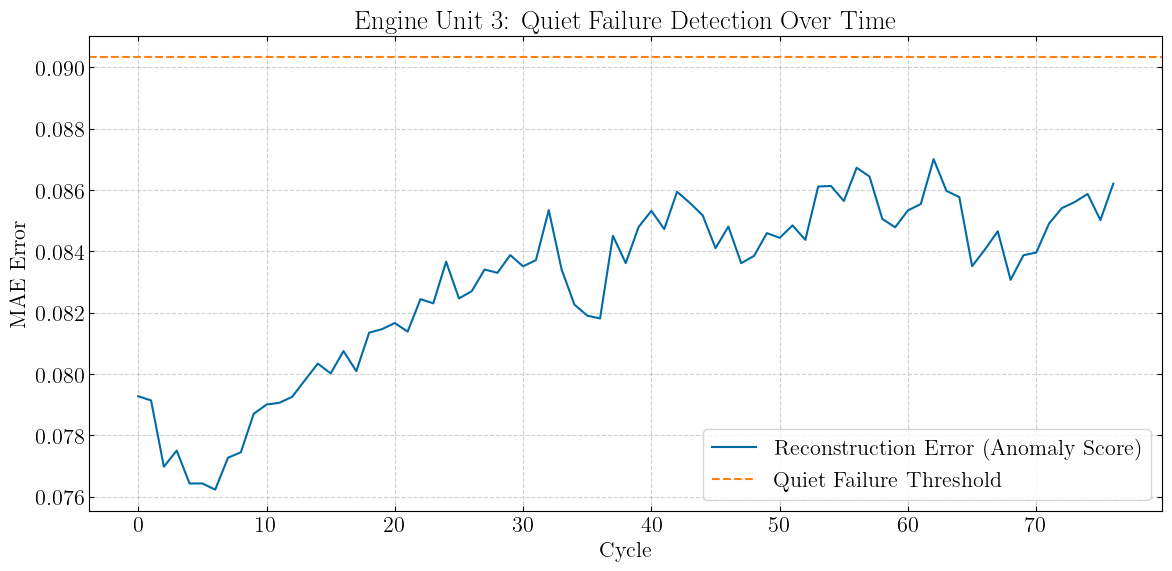

In [26]:
fig = failure_plot(anomaly_score, threshold, unit_no=3)
plt.show()

In [33]:
# 1. Get the sequences (Using your 'ops' and 'health_sensors' lists)
X_input_seq, Y_actual_seq = get_engine_history_multi(
    df_test, 
    unit_id=17,
    window_size=wsize, 
    op_cols=ops, 
    sensor_cols=relevant_sensors
)

# 2. Predict (Model takes 16-col input, gives 14-col output)
reconstructed = model.predict(X_input_seq)

# 3. Calculate Anomaly Score
# Compare the (samples, 30, 14) reconstruction to the (samples, 30, 14) actuals
anomaly_score = np.mean(np.abs(Y_actual_seq - reconstructed), axis=(1, 2))

# 4. Detection Logic
try:
    # Adding +wsize gives you the actual 'Cycle' on the X-axis of the original data
    alert_cycle = np.where(anomaly_score > threshold)[0][0]
    print(f"Quiet Failure detected at Cycle: {alert_cycle}")
except IndexError:
    print('No Failure detected above threshold.')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Quiet Failure detected at Cycle: 70


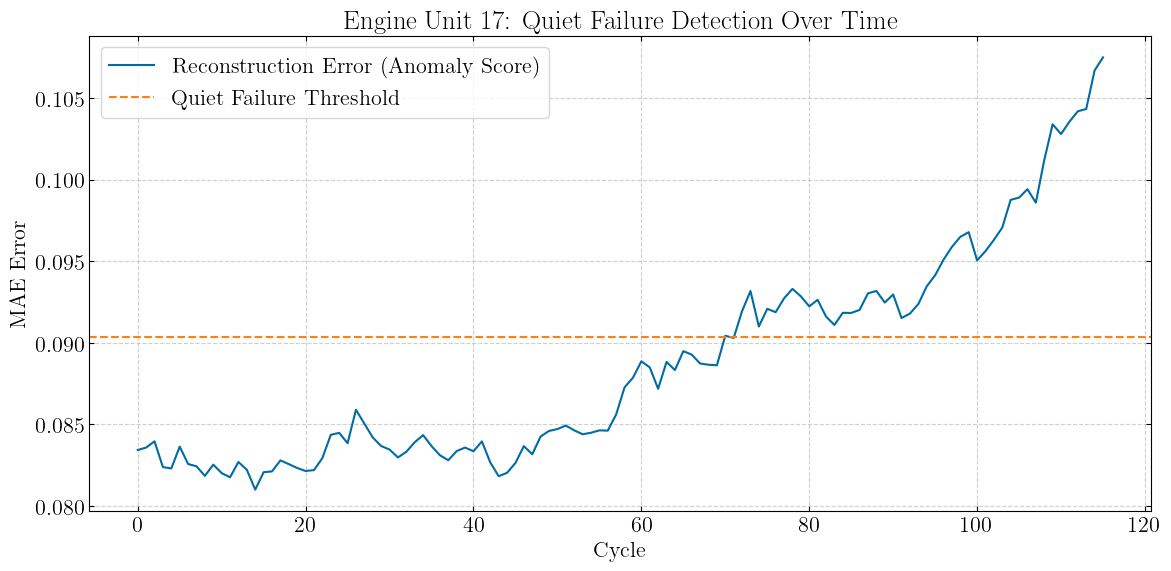

In [31]:
fig = failure_plot(anomaly_score, threshold, unit_no=17)
plt.show()

In [ ]:
col_names = ['Unit', 'Cycle Time', 'Op1', 'Op2', 'Op3'] + [f'Sensor {_+1}' for _ in range(23)]
df = pd.read_csv(os.path.join(path, 'train_FD004.txt'), sep=' ', header=None, names=col_names)
df_test = pd.read_csv(os.path.join(path, 'test_FD004.txt'), sep=' ', header=None, names=col_names)

In [ ]:
df.head()

,Unit,Cycle Time,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,...,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Sensor 22,Sensor 23,Sensor 24,Sensor 25,Sensor 26
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,NaN,NaN
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,NaN,NaN
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,NaN,NaN
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,NaN,NaN
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,NaN,NaN


In [ ]:
# Using to_string with specific formatting
with open('data_summary_FD004.txt', 'w') as f:
    f.write("CMAPSS Dataset Summary Statistics\n")
    f.write("="*30 + "\n")
    f.write(df.describe().transpose().to_string()) # Transpose makes it easier to read if you have many sensors

In [ ]:
cols_to_drop = ['Sensor 25', 'Sensor 26']
relevant_sensors = [f'Sensor {_+1}' for _ in range(24)]
df = df.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)
df.head()

,Unit,Cycle Time,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,...,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Sensor 22,Sensor 23,Sensor 24
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


In [ ]:
df[relevant_sensors] = df[relevant_sensors].astype('float64')
df_test[relevant_sensors] = df_test[relevant_sensors].astype('float64')

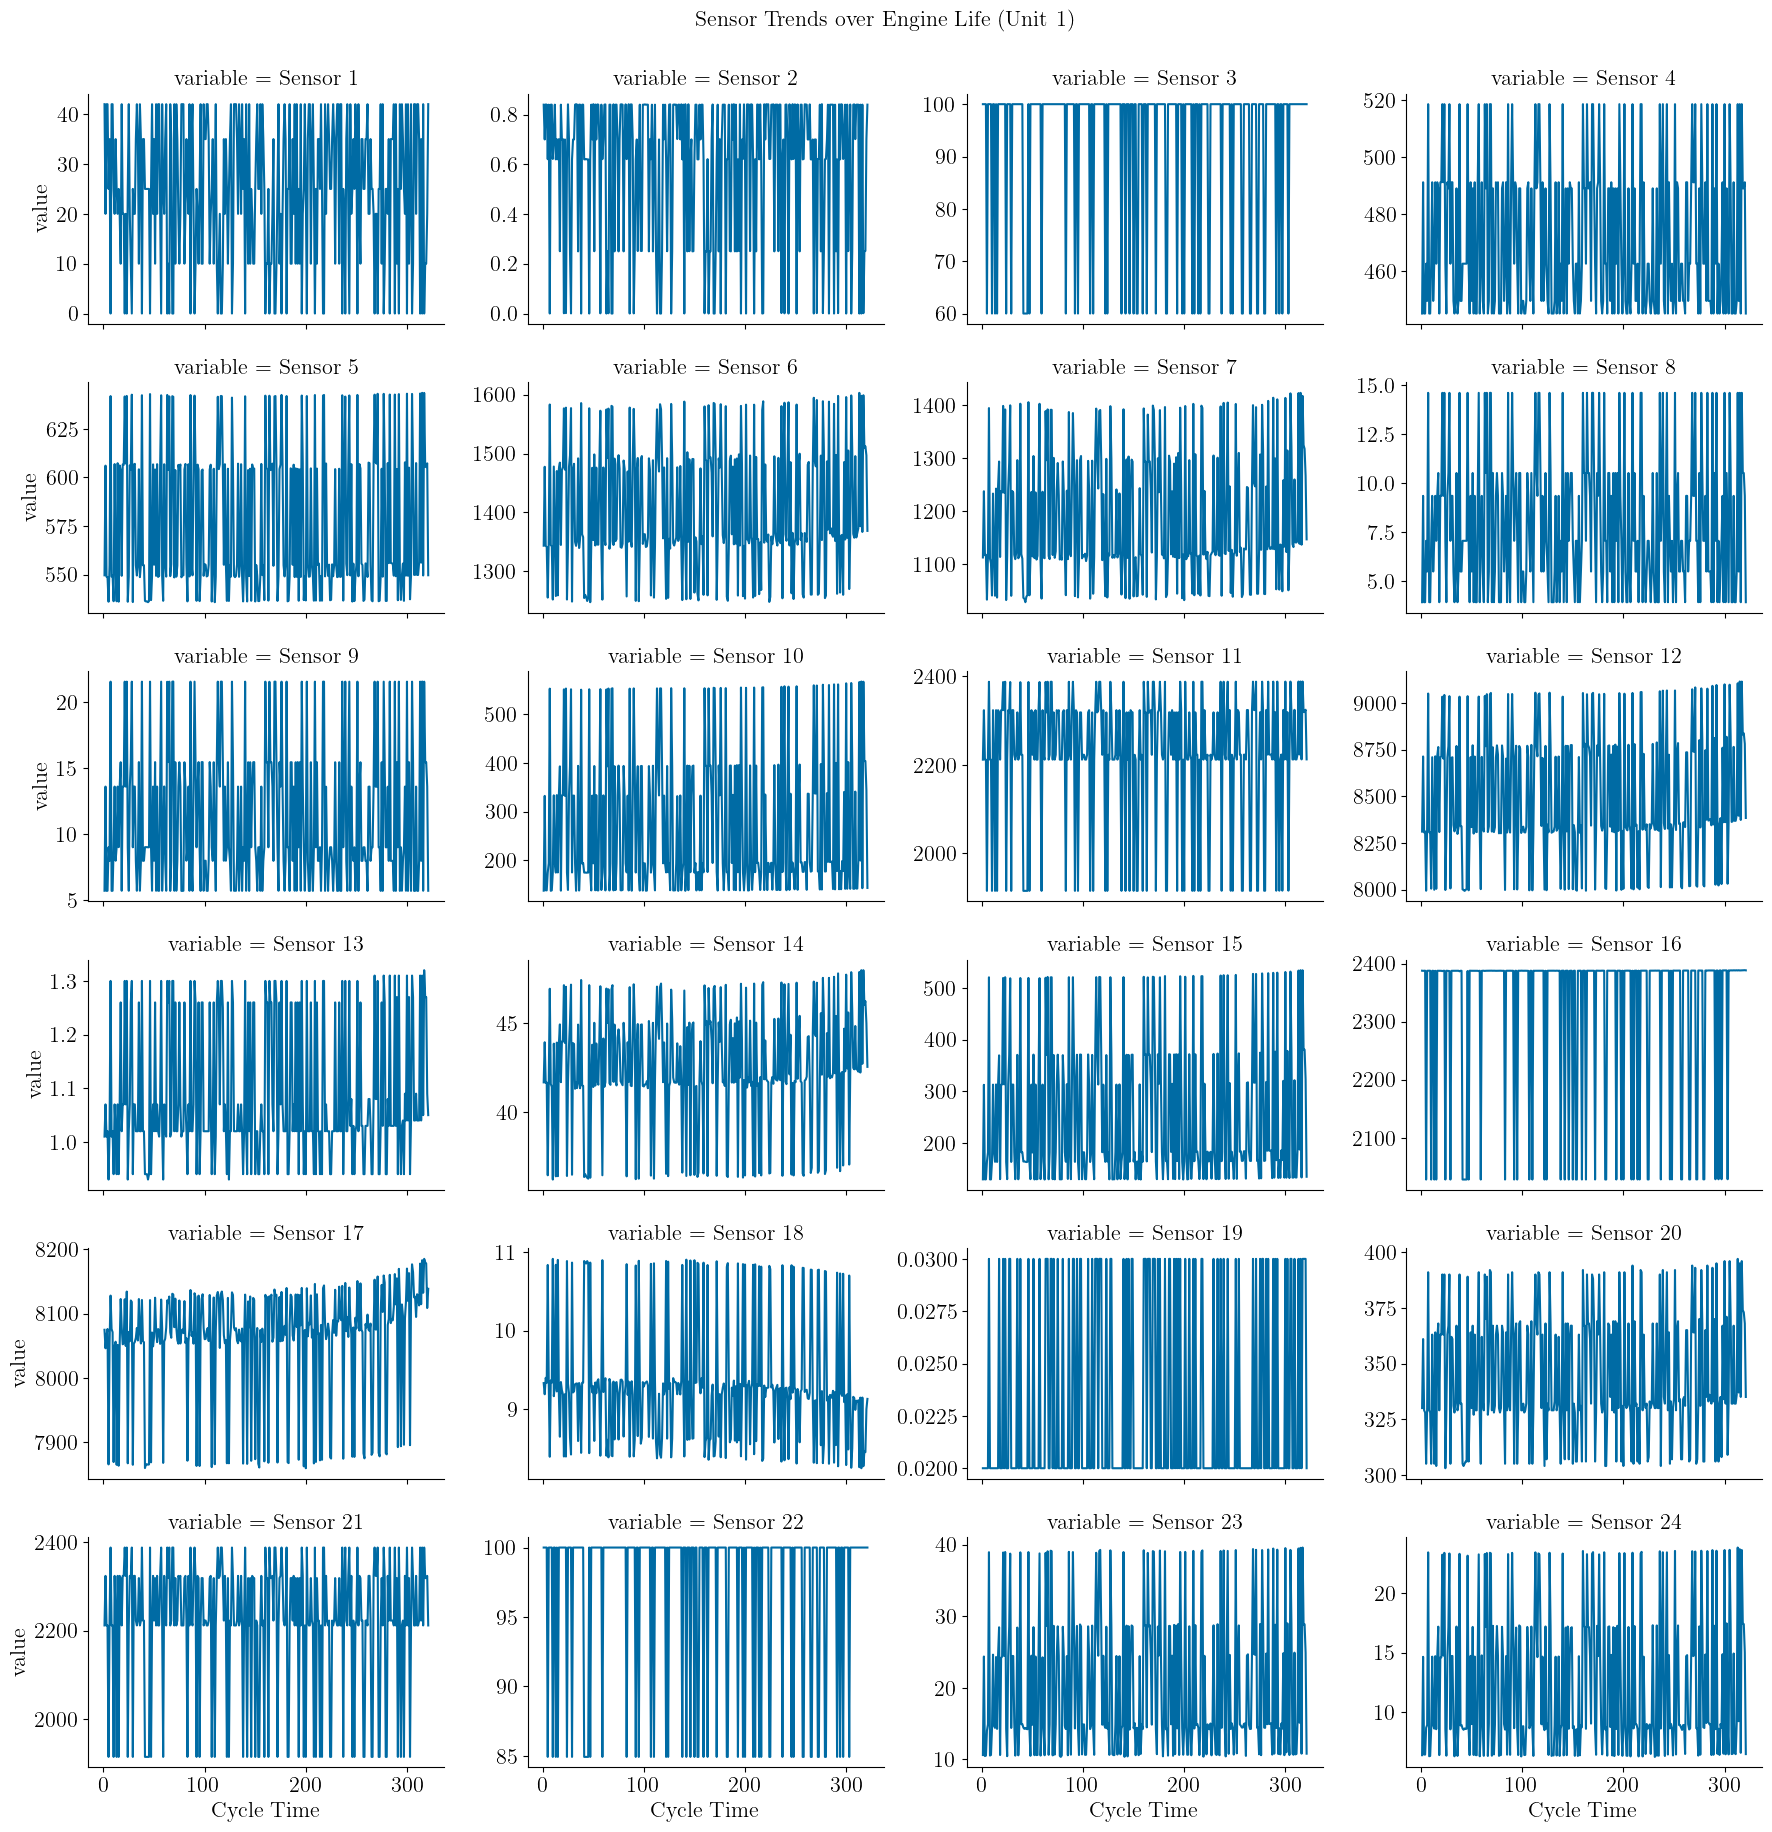

In [ ]:
unit_data = df[df['Unit'] == 1]
plot_data = unit_data.melt(id_vars='Cycle Time', value_vars=relevant_sensors)

# 2. Create a grid of plots
g = sns.FacetGrid(plot_data, col="variable", col_wrap=4, sharey=False, aspect=1.5)
g.map(sns.lineplot, "Cycle Time", "value")

# Add a title and adjust layout
g.fig.suptitle('Sensor Trends over Engine Life (Unit 1)', y=1.02, fontsize=16)
plt.show()

In [ ]:
cols_to_drop = ['Sensor 16', 'Sensor 19', 'Sensor 22']
df = df.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)

In [ ]:
relevant_sensors.remove('Sensor 16')
relevant_sensors.remove('Sensor 19')
relevant_sensors.remove('Sensor 22')

In [ ]:
print(relevant_sensors)
print(len(relevant_sensors))

['Sensor 1', 'Sensor 2', 'Sensor 3', 'Sensor 4', 'Sensor 5', 'Sensor 6', 'Sensor 7', 'Sensor 8', 'Sensor 9', 'Sensor 10', 'Sensor 11', 'Sensor 12', 'Sensor 13', 'Sensor 14', 'Sensor 15', 'Sensor 17', 'Sensor 18', 'Sensor 20', 'Sensor 21', 'Sensor 23', 'Sensor 24']
21


In [ ]:
# 1. Create a Global Scaler based ONLY on Train
global_scaler = MinMaxScaler()

# We only fit on the 'Healthy' starts of the training engines
# to define what "Healthy" looks like across all regimes.
healthy_train_data = []
for unit in df['Unit'].unique():
    healthy_train_data.append(df[df['Unit'] == unit][relevant_sensors].iloc[:30])

# Combine all healthy starts into one pool and fit
healthy_pool = pd.concat(healthy_train_data)
global_scaler.fit(healthy_pool)

# 2. Now use this ONE scaler to transform everything
df[relevant_sensors] = global_scaler.transform(df[relevant_sensors])
df_test[relevant_sensors] = global_scaler.transform(df_test[relevant_sensors])

In [ ]:
def gen_train_windows_multi(df, window_size):
    X = []
    for unit in df['Unit'].unique():
        unit_data = df[df['Unit'] == unit][relevant_sensors].values
        # Using first 50 cycles as healthy baseline
        healthy_data = unit_data[:50] 
        if len(healthy_data) >= window_size:
            for i in range(len(healthy_data) - window_size + 1):
                X.append(healthy_data[i:i+window_size])
    return np.array(X)

X_train_multi = gen_train_windows_multi(df, wsize)

In [ ]:
n_features = len(relevant_sensors)

# Define the Input layer
inputs = Input(shape=(wsize, n_features))

# ENCODER
# The LSTM processes both the sensors and the context together
encoder = LSTM(64, activation='tanh', return_sequences=False)(inputs)

# BOTTLENECK
bottleneck = RepeatVector(wsize)(encoder)

# DECODER
decoder = LSTM(64, activation='tanh', return_sequences=True)(bottleneck)

# OUTPUT
# We reconstruct the SENSORS ONLY (ignore op settings in the output)
# This forces the model to use Op Settings as a guide, not a target
outputs = TimeDistributed(Dense(len(relevant_sensors)))(decoder)

model = keras.models.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='mae')

In [ ]:
print(X_train_multi.shape)
print(X_train_multi[:, :, 3:].shape)

(5229, 30, 21)
(5229, 30, 18)


In [ ]:
# Slice X_train to get just the sensor columns for the target
# Assuming Op Settings are the first 3 columns
Y_train_sensors = X_train_multi[:, :, 3:] 

history = model.fit(
    X_train_multi, Y_train_sensors, 
    epochs=50, 
    batch_size=64, 
    validation_split=0.1,
    callbacks=callbacks
)

Epoch 1/50


ValueError: Dimensions must be equal, but are 18 and 21 for '{{node compile_loss/mae/sub}} = Sub[T=DT_FLOAT](data_1, functional_5_1/time_distributed_1_1/transpose_1)' with input shapes: [?,30,18], [?,30,21].

/opt/miniconda3/envs/hai/lib/python3.11/site-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/opt/miniconda3/envs/hai/lib/python3.11/site-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


Epoch 1/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: nan - val_loss: nan - learning_rate: 0.0010
Epoch 2/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: nan - val_loss: nan - learning_rate: 0.0010
Epoch 3/50
 81/158 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: nan

KeyboardInterrupt: 